# Experiment: RRWNet for Artery–Vein Segmentation on GAVE2 Dataset

## Objective

The objective of this experiment is to implement and evaluate **RRWNet (Recursive Refinement Network)** for multiclass retinal vessel segmentation on the GAVE2 dataset.

The segmentation task consists of classifying each pixel into one of four classes:

* Class 0 → Background
* Class 1 → Artery
* Class 2 → Overlap (Artery–Vein crossing)
* Class 3 → Vein

The primary goal is to improve:

* Vessel continuity
* Thin vessel segmentation
* Overlap detection
* Topological consistency of vascular structures

---

# Dataset

Dataset used: **GAVE2 Preliminary Dataset**

Directory structure:

```text
training/
│
├── images/     → RGB fundus images
├── av/         → RGB artery-vein ground truth masks
└── masks/      → Binary ROI/FOV masks
```

### Input Images

* Retinal fundus RGB images
* Original resolution: **1536 × 1024**

### Ground Truth AV Masks

RGB encoded masks:

* Red → Artery
* Green → Overlap
* Blue → Vein

### ROI Masks

Binary masks defining the valid Field of View (FOV).

These masks are used to:

* Remove irrelevant black background
* Restrict learning to retinal region only

---

# Why RRWNet?

RRWNet is specifically designed for retinal vessel segmentation.

Its key advantages:

* Strong local feature extraction using U-Net style encoder-decoder
* Recursive refinement of predictions
* Better vessel continuity
* Improved thin vessel recovery
* More suitable for vascular topology compared to standard segmentation models

Unlike conventional U-Net, RRWNet performs multiple iterative refinements on predicted vessel maps.

---

# Preprocessing

We adopted image enhancement inspired by the original RRWNet preprocessing pipeline.

## Steps

### 1. ROI Masking

The binary ROI mask is applied to retain only retinal region.

Purpose:

* Remove irrelevant dark background
* Focus model learning on useful regions

---

### 2. Image Enhancement

The following enhancement pipeline is applied:

* Slight image zoom
* Gaussian smoothing
* Background subtraction
* Contrast enhancement
* Intensity normalization

This improves:

* Vessel visibility
* Contrast between arteries and veins
* Thin vessel representation

---

### 3. Augmentation

To improve generalization, several augmentations are applied:

* Horizontal Flip
* Vertical Flip
* Rotation
* Color Jitter
* Elastic Deformation

These augmentations help model learn:

* Robust vessel patterns
* Variations in illumination
* Shape deformations

---

# Class Imbalance

The dataset is heavily imbalanced.

Typical class distribution:

* Background → Dominant
* Artery → Moderate
* Vein → Moderate
* Overlap → Extremely rare

Overlap pixels form a very small percentage of total pixels.

This makes overlap segmentation particularly difficult.

To address this, weighted losses are used.

Class weights:

```python
[1.0, 6.0, 40.0, 6.0]
```

Meaning:

* Low weight for background
* Medium weight for artery and vein
* High weight for overlap

---

# RRWNet Architecture

RRWNet consists of two U-Net modules.

## Architecture Flow

```text
Input Fundus Image
        ↓
 First U-Net Module
        ↓
 Initial Segmentation Prediction
        ↓
 Recursive Refinement U-Net
        ↓
 Refined Prediction
        ↓
 Final Output
```

---

## Recursive Refinement

The first U-Net produces an initial segmentation.

The second U-Net repeatedly refines this prediction.

Refinement iterations:

* K = 3 or K = 5 depending on experiment

This allows the model to:

* Correct segmentation mistakes
* Improve vessel continuity
* Refine vessel boundaries

---

# Loss Function

A hybrid loss function is used to optimize both:

* Pixel accuracy
* Vessel topology

## Combined Loss

```text
Total Loss =
0.15 × CrossEntropy
+ 0.20 × Focal Loss
+ 0.30 × Tversky Loss
+ 0.35 × CLDice Loss
```

---

## Loss Components

### Cross Entropy Loss

Handles multiclass segmentation.

Improves:

* Pixel-wise classification accuracy

---

### Focal Loss

Addresses class imbalance.

Improves:

* Learning on difficult minority classes
* Overlap segmentation

---

### Tversky Loss

Balances false positives and false negatives.

Important for:

* Thin vessel segmentation

---

### CLDice Loss

Topology-aware loss.

Improves:

* Vessel connectivity
* Structural continuity
* Reduced broken vessels

---

# Training Configuration

## Optimizer

Adam optimizer

Learning Rate:

```python
1e-4
```

---

## Training Parameters

* Batch Size: Experiment dependent
* Epochs: 20–40
* Device: CUDA GPU (24 GB VRAM)

---

# Evaluation Metrics

Model performance is evaluated using:

* Accuracy
* Precision
* Recall
* F1 Score
* IoU
* Dice Score

Metrics are computed for:

* Artery
* Overlap
* Vein

Additionally:

* Binary vessel segmentation metrics are also evaluated

---

# Current Challenges

The main challenges in this problem are:

## 1. Severe Class Imbalance

Overlap pixels are extremely rare.

---

## 2. Thin Vessel Detection

Very thin vessels are difficult to segment.

---

## 3. Artery–Vein Classification

Vessel segmentation may work well, but distinguishing artery vs vein remains difficult.

---

## 4. Topological Consistency

Broken vessel branches reduce segmentation quality.

---

# Expected Outcome

RRWNet is expected to improve:

* Vessel continuity
* Topological consistency
* Thin vessel detection
* Overlap segmentation

The final goal is to achieve high performance in:

* Precision
* F1 Score
* Structural vessel continuity


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import scipy.ndimage as ndimage
from scipy.interpolate import interp1d
from skimage.morphology import disk

In [ ]:
BASE_PATH = r"C:\Users\HP\Desktop\GAVE2_preliminary"

IMAGE_DIR = os.path.join(BASE_PATH, "training", "images")
AV_DIR = os.path.join(BASE_PATH, "training", "av")
MASK_DIR = os.path.join(BASE_PATH, "training", "masks")

device = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 1
LR = 1e-4
EPOCHS = 20
IMAGE_HEIGHT = 1024
IMAGE_WIDTH = 1536

In [3]:
def crop_center(img, cropx, cropy):
    y, x = img.shape[:2]
    startx = x//2 - cropx//2
    starty = y//2 - cropy//2
    return img[starty:starty+cropy, startx:startx+cropx]


def to_0_1(img):
    interp_fun = interp1d([img.min(), img.max()], [0.0, 1.0])
    return interp_fun(img)


def enhance_image(img, roi_mask, disk_size=5):
    img = img.astype(np.float32) / 255.0
    roi_mask = (roi_mask > 127).astype(np.uint8)

    img_copy = img.copy()

    zoomed = Image.fromarray(np.uint8(img_copy * 255))
    zoomed = zoomed.resize(
        (int(img_copy.shape[1]*1.15), int(img_copy.shape[0]*1.15)),
        Image.BICUBIC
    )
    zoomed = np.array(zoomed)
    zoomed = crop_center(zoomed, img_copy.shape[1], img_copy.shape[0])
    zoomed = zoomed / 255.0

    kernel = disk(disk_size)
    roi_mask = ndimage.binary_erosion(roi_mask, kernel)
    roi_mask = roi_mask.astype(np.float32)

    img_copy[roi_mask < 1] = 0

    roi_rgb = np.stack([roi_mask]*3, axis=2)

    composed = roi_rgb.copy()
    composed[roi_rgb == 1] = img_copy[roi_rgb == 1]
    composed[roi_rgb < 1] = zoomed[roi_rgb < 1]

    filtered = ndimage.gaussian_filter(composed, sigma=(10, 10, 0))

    subtracted = composed - filtered
    subtracted[roi_rgb < 1] = 0

    enhanced = subtracted / np.std(subtracted)
    enhanced = to_0_1(enhanced)
    enhanced[roi_rgb < 1] = 0

    return enhanced

In [4]:
def rgb_to_class_mask(mask):
    h, w, _ = mask.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)

    artery = np.all(mask == [255, 0, 0], axis=-1)
    overlap = np.all(mask == [0, 255, 0], axis=-1)
    vein = np.all(mask == [0, 0, 255], axis=-1)

    class_mask[artery] = 1
    class_mask[overlap] = 2
    class_mask[vein] = 3

    return class_mask

In [5]:
class GAVE2Dataset(Dataset):
    def __init__(self, image_paths, av_paths, roi_paths, transform=None):
        self.transform = transform
        self.samples = []

        print("Caching dataset...")

        for i in range(len(image_paths)):
            image = cv2.imread(image_paths[i])
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            av_mask = cv2.imread(av_paths[i])
            av_mask = cv2.cvtColor(av_mask, cv2.COLOR_BGR2RGB)

            roi_mask = cv2.imread(roi_paths[i], cv2.IMREAD_GRAYSCALE)

            image = enhance_image(image, roi_mask)
            image = image.astype(np.float32)

            mask = rgb_to_class_mask(av_mask)

            self.samples.append((image, mask))

        print("Caching complete.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image, mask = self.samples[idx]

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        image = image.float()

        if torch.is_tensor(mask):
            mask = mask.long()
        else:
            mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [6]:
train_transform = A.Compose([
    A.Resize(512, 768),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, p=0.5),

    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
        p=0.5
    ),

    A.ElasticTransform(alpha=20, sigma=6, p=0.3),

    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 768),
    ToTensorV2()
])

In [7]:
image_files = sorted([
    os.path.join(IMAGE_DIR, x)
    for x in os.listdir(IMAGE_DIR)
])

av_files = sorted([
    os.path.join(AV_DIR, x)
    for x in os.listdir(AV_DIR)
])

roi_files = sorted([
    os.path.join(MASK_DIR, x)
    for x in os.listdir(MASK_DIR)
])

print(len(image_files), len(av_files), len(roi_files))

50 50 50


In [8]:
train_imgs, val_imgs, train_av, val_av, train_roi, val_roi = train_test_split(
    image_files,
    av_files,
    roi_files,
    test_size=0.30,
    random_state=42
)

In [9]:
train_dataset = GAVE2Dataset(
    train_imgs,
    train_av,
    train_roi,
    transform=train_transform
)

val_dataset = GAVE2Dataset(
    val_imgs,
    val_av,
    val_roi,
    transform=val_transform
)

Caching dataset...
Caching complete.
Caching dataset...
Caching complete.


In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

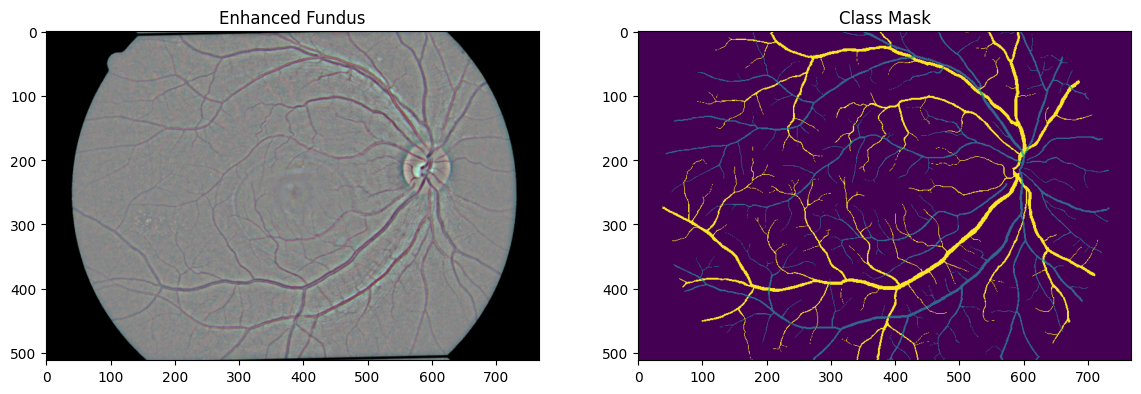

In [11]:
images, masks = next(iter(train_loader))

img = images[0].permute(1,2,0).cpu().numpy()
mask = masks[0].cpu().numpy()

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Enhanced Fundus")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Class Mask")

plt.show()

In [12]:
print(np.unique(mask))

[0 1 2 3]


In [13]:
for c in range(4):
    print(f"Class {c}: {(mask == c).sum()}")

Class 0: 359820
Class 1: 15724
Class 2: 345
Class 3: 17327


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UpConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_ch, out_ch,
            kernel_size=2,
            stride=2
        )

    def forward(self, x):
        return self.up(x)


class UNetModule(nn.Module):
    def __init__(self, in_ch, out_ch, base_ch=32):
        super().__init__()

        self.c1 = ConvBlock(in_ch, base_ch)
        self.c2 = ConvBlock(base_ch, base_ch * 2)
        self.c3 = ConvBlock(base_ch * 2, base_ch * 4)
        self.c4 = ConvBlock(base_ch * 4, base_ch * 8)
        self.c5 = ConvBlock(base_ch * 8, base_ch * 16)

        self.u1 = UpConv(base_ch * 16, base_ch * 8)
        self.c6 = ConvBlock(base_ch * 16, base_ch * 8)

        self.u2 = UpConv(base_ch * 8, base_ch * 4)
        self.c7 = ConvBlock(base_ch * 8, base_ch * 4)

        self.u3 = UpConv(base_ch * 4, base_ch * 2)
        self.c8 = ConvBlock(base_ch * 4, base_ch * 2)

        self.u4 = UpConv(base_ch * 2, base_ch)
        self.c9 = ConvBlock(base_ch * 2, base_ch)

        self.out = nn.Conv2d(base_ch, out_ch, 1)

    def forward(self, x):
        x1 = self.c1(x)
        x2 = self.c2(F.max_pool2d(x1, 2))
        x3 = self.c3(F.max_pool2d(x2, 2))
        x4 = self.c4(F.max_pool2d(x3, 2))
        x5 = self.c5(F.max_pool2d(x4, 2))

        x = self.u1(x5)
        x = torch.cat([x4, x], dim=1)
        x = self.c6(x)

        x = self.u2(x)
        x = torch.cat([x3, x], dim=1)
        x = self.c7(x)

        x = self.u3(x)
        x = torch.cat([x2, x], dim=1)
        x = self.c8(x)

        x = self.u4(x)
        x = torch.cat([x1, x], dim=1)
        x = self.c9(x)

        return self.out(x)


class RRWNet(nn.Module):
    def __init__(self, base_ch=32, iterations=3):
        super().__init__()

        self.first_u = UNetModule(
            in_ch=3,
            out_ch=4,
            base_ch=base_ch
        )

        self.second_u = UNetModule(
            in_ch=4,
            out_ch=4,
            base_ch=base_ch
        )

        self.iterations = iterations

    def forward(self, x):
        predictions = []

        pred1 = self.first_u(x)
        predictions.append(pred1)

        pred_ref = pred1

        for _ in range(self.iterations):
            pred_soft = torch.softmax(pred_ref, dim=1)
            pred_ref = self.second_u(pred_soft)
            predictions.append(pred_ref)

        return predictions

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = RRWNet(
    base_ch=32,
    iterations=3
).to(device)

print(f"Using device: {device}")

Using device: cuda


In [16]:
images, masks = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print(type(outputs))
print(len(outputs))
print(outputs[-1].shape)

<class 'list'>
4
torch.Size([2, 4, 512, 768])


In [17]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

In [18]:
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, 4).permute(0,3,1,2).float()

        tp = (probs * targets_one_hot).sum((2,3))
        fp = (probs * (1 - targets_one_hot)).sum((2,3))
        fn = ((1 - probs) * targets_one_hot).sum((2,3))

        tversky = (tp + self.smooth) / (
            tp + self.alpha * fp + self.beta * fn + self.smooth
        )

        return 1 - tversky.mean()

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def soft_erode(img):
    if len(img.shape) == 4:
        p1 = -F.max_pool2d(-img, (3,1), (1,1), (1,0))
        p2 = -F.max_pool2d(-img, (1,3), (1,1), (0,1))
        return torch.min(p1, p2)


def soft_dilate(img):
    if len(img.shape) == 4:
        return F.max_pool2d(img, (3,3), (1,1), (1,1))


def soft_open(img):
    return soft_dilate(soft_erode(img))


def soft_skeletonize(img, iterations=10):
    img1 = soft_open(img)
    skel = F.relu(img - img1)

    for _ in range(iterations):
        img = soft_erode(img)
        img1 = soft_open(img)
        delta = F.relu(img - img1)
        skel = skel + F.relu(delta - skel * delta)

    return skel


class SoftCLDiceLoss(nn.Module):
    def __init__(self, iterations=10):
        super().__init__()
        self.iterations = iterations

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)

        pred_vessel = probs[:,1:2] + probs[:,2:3] + probs[:,3:4]
        gt_vessel = (targets > 0).float().unsqueeze(1)

        pred_skel = soft_skeletonize(pred_vessel, self.iterations)
        gt_skel = soft_skeletonize(gt_vessel, self.iterations)

        tprec = (pred_skel * gt_vessel).sum(dim=(1,2,3)) / (pred_skel.sum(dim=(1,2,3)) + 1e-6)
        tsens = (gt_skel * pred_vessel).sum(dim=(1,2,3)) / (gt_skel.sum(dim=(1,2,3)) + 1e-6)

        cl_dice = (2 * tprec * tsens) / (tprec + tsens + 1e-6)

        return 1 - cl_dice.mean()

In [20]:
class CombinedLoss(nn.Module):
    def __init__(self, class_weights):
        super().__init__()

        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.focal = FocalLoss(alpha=class_weights)
        self.tversky = TverskyLoss()
        self.cldice = SoftCLDiceLoss()

    def forward(self, outputs, targets):
        ce_loss = self.ce(outputs, targets)
        focal_loss = self.focal(outputs, targets)
        tversky_loss = self.tversky(outputs, targets)
        cldice_loss = self.cldice(outputs, targets)

        total_loss = (
            0.10 * ce_loss +
            0.15 * focal_loss +
            0.25 * tversky_loss +
            0.50 * cldice_loss
        )

        return total_loss

In [21]:
def rrwnet_loss(outputs, targets, criterion):
    total_loss = 0

    for pred in outputs:
        total_loss += criterion(pred, targets)

    return total_loss / len(outputs)

In [22]:
class_weights = torch.tensor([1.0, 6.0, 40.0, 6.0]).to(device)

criterion = CombinedLoss(class_weights)

In [23]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

In [24]:
def compute_accuracy(outputs, masks):
    preds = torch.argmax(outputs[-1], dim=1)
    correct = (preds == masks).float().sum()
    total = masks.numel()
    return (correct / total).item()

In [25]:
def multiclass_dice(outputs, masks, smooth=1e-6):
    preds = torch.argmax(outputs[-1], dim=1)

    dice_scores = []

    for cls in [1, 2, 3]:
        pred_cls = (preds == cls).float()
        mask_cls = (masks == cls).float()

        intersection = (pred_cls * mask_cls).sum()
        union = pred_cls.sum() + mask_cls.sum()

        dice = (2 * intersection + smooth) / (union + smooth)
        dice_scores.append(dice)

    return torch.mean(torch.stack(dice_scores)).item()

In [26]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_acc = 0
    total_dice = 0

    for images, masks in tqdm(loader):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = rrwnet_loss(outputs, masks, criterion)

        loss.backward()
        optimizer.step()

        acc = compute_accuracy(outputs, masks)
        dice = multiclass_dice(outputs, masks)

        total_loss += loss.item()
        total_acc += acc
        total_dice += dice

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_dice / len(loader)
    )

In [27]:
def validate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_acc = 0
    total_dice = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = rrwnet_loss(outputs, masks, criterion)

            acc = compute_accuracy(outputs, masks)
            dice = multiclass_dice(outputs, masks)

            total_loss += loss.item()
            total_acc += acc
            total_dice += dice

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_dice / len(loader)
    )

In [28]:
best_val_dice = 0
EPOCHS = 20

for epoch in range(EPOCHS):

    train_loss, train_acc, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_dice = validate(
        model, val_loader, criterion
    )
    
    if val_dice > best_val_dice:
        best_val_dice = val_dice


        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "best_val_dice": best_val_dice
        }, "best_rrwnet.pth")



    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train Dice: {train_dice:.4f}"
    )
    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Dice: {val_dice:.4f}"
    )
    print("-"*50)

100%|██████████| 18/18 [00:07<00:00,  2.32it/s]


Epoch 1/20
Train Loss: 0.9742 | Train Acc: 0.1498 | Train Dice: 0.0477
Val Loss: 0.9780 | Val Acc: 0.9170 | Val Dice: 0.0025
--------------------------------------------------


100%|██████████| 18/18 [00:07<00:00,  2.38it/s]


Epoch 2/20
Train Loss: 0.8406 | Train Acc: 0.5825 | Train Dice: 0.1059
Val Loss: 0.8832 | Val Acc: 0.7230 | Val Dice: 0.0641
--------------------------------------------------


100%|██████████| 18/18 [00:07<00:00,  2.45it/s]


...

Epoch 18/20
Train Loss: 0.4666 | Train Acc: 0.9257 | Train Dice: 0.3536
Val Loss: 0.4762 | Val Acc: 0.9335 | Val Dice: 0.3367
--------------------------------------------------


100%|██████████| 18/18 [00:07<00:00,  2.40it/s]


Epoch 19/20
Train Loss: 0.4595 | Train Acc: 0.9264 | Train Dice: 0.3602
Val Loss: 0.4757 | Val Acc: 0.9274 | Val Dice: 0.3359
--------------------------------------------------


100%|██████████| 18/18 [00:07<00:00,  2.32it/s]


Epoch 20/20
Train Loss: 0.4541 | Train Acc: 0.9279 | Train Dice: 0.3659
Val Loss: 0.4685 | Val Acc: 0.9196 | Val Dice: 0.3322
--------------------------------------------------


In [29]:
checkpoint = torch.load("best_rrwnet.pth")
model.load_state_dict(checkpoint["model_state_dict"])

print("Best epoch:", checkpoint["epoch"] + 1)
print("Best val dice:", checkpoint["best_val_dice"])

Best epoch: 18
Best val dice: 0.33669551834464073


In [30]:
def mask_to_rgb(mask):
    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    rgb[mask == 1] = [255, 0, 0]   # artery
    rgb[mask == 2] = [0, 255, 0]   # overlap
    rgb[mask == 3] = [0, 0, 255]   # vein

    return rgb

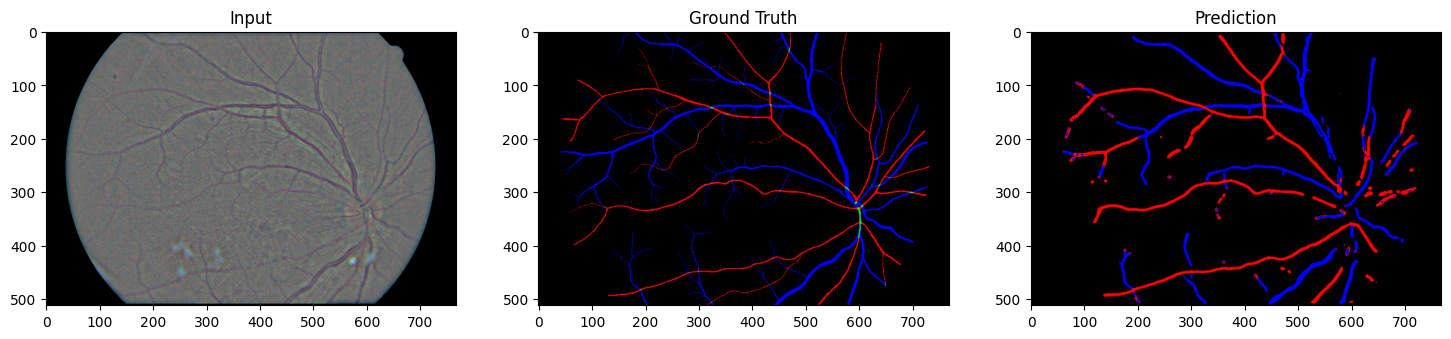

In [31]:
checkpoint = torch.load("best_rrwnet.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

preds = torch.argmax(outputs[-1], dim=1).cpu().numpy()

img = images[0].cpu().permute(1,2,0).numpy()
gt = masks[0].cpu().numpy()
pred = preds[0]

gt_rgb = mask_to_rgb(gt)
pred_rgb = mask_to_rgb(pred)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(gt_rgb)
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_rgb)
plt.title("Prediction")

plt.show()

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

In [33]:
def evaluate_multiclass_metrics(model, loader):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs[-1], dim=1).cpu().numpy()

            all_preds.extend(preds.flatten())
            all_targets.extend(masks.numpy().flatten())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    class_names = {
        1: "Artery",
        2: "Overlap",
        3: "Vein"
    }

    print("MULTICLASS METRICS")
    print("="*60)

    precisions = []
    recalls = []
    f1s = []
    ious = []

    for cls in [1, 2, 3]:
        pred_binary = (all_preds == cls).astype(np.uint8)
        target_binary = (all_targets == cls).astype(np.uint8)

        precision = precision_score(target_binary, pred_binary, zero_division=0)
        recall = recall_score(target_binary, pred_binary, zero_division=0)
        f1 = f1_score(target_binary, pred_binary, zero_division=0)
        iou = jaccard_score(target_binary, pred_binary, zero_division=0)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        ious.append(iou)

        print(class_names[cls])
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")
        print(f"F1 Score  : {f1:.4f}")
        print(f"IoU       : {iou:.4f}")
        print("-"*60)

    print("\nMACRO AVERAGES")
    print("="*60)
    print(f"Precision : {np.mean(precisions):.4f}")
    print(f"Recall    : {np.mean(recalls):.4f}")
    print(f"F1 Score  : {np.mean(f1s):.4f}")
    print(f"IoU       : {np.mean(ious):.4f}")

In [34]:
checkpoint = torch.load("best_rrwnet.pth")
model.load_state_dict(checkpoint["model_state_dict"])

evaluate_multiclass_metrics(model, val_loader)

MULTICLASS METRICS
Artery
Precision : 0.3537
Recall    : 0.5669
F1 Score  : 0.4356
IoU       : 0.2784
------------------------------------------------------------
Overlap
Precision : 0.0625
Recall    : 0.0013
F1 Score  : 0.0025
IoU       : 0.0013
------------------------------------------------------------
Vein
Precision : 0.5153
Recall    : 0.6992
F1 Score  : 0.5934
IoU       : 0.4218
------------------------------------------------------------

MACRO AVERAGES
Precision : 0.3105
Recall    : 0.4225
F1 Score  : 0.3438
IoU       : 0.2338
